In [2]:
# Install required packages (run once, then you can skip this cell)
# sentence-transformers: free, open-source embedding models (no API key needed)
# scikit-learn: we'll use it for cosine similarity calculation
# matplotlib: for visualizing embeddings as charts and plots
%pip install langchain langchain-community sentence-transformers scikit-learn matplotlib

  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 571.3/571.3 kB 3.3 MB/s  0:00:00
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   --- -----------------

c:\Users\Dell\.conda\envs\hts_rag\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Dell\.conda\envs\hts_rag\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dell\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to a

Cosine similarity between sentence 1 and sentence 2: 0.8524


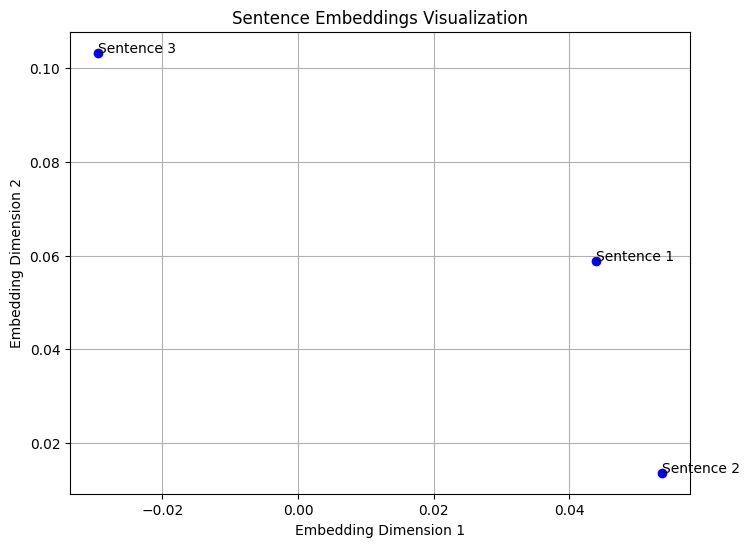

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
# Load a pre-trained sentence embedding model (this will download the model the first time you run it)
model = SentenceTransformer('all-MiniLM-L6-v2')  # A popular, lightweight model for generating sentence embeddings
# Example sentences to embed
sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "A fast brown fox leaps over a sleepy dog.",
    "The weather is nice today."
]
# Generate embeddings for the sentences
embeddings = model.encode(sentences)


# Calculate cosine similarity between the first two sentences
similarity = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
print(f"Cosine similarity between sentence 1 and sentence 2: {similarity:.4f}")
# Visualize the embeddings using a simple scatter plot (for demonstration purposes)
plt.figure(figsize=(8, 6))
plt.scatter(embeddings[:, 0], embeddings[:, 1], color='blue')
for i, sentence in enumerate(sentences):
    plt.annotate(f"Sentence {i+1}", (embeddings[i, 0], embeddings[i, 1]))
plt.title("Sentence Embeddings Visualization")
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.grid()
plt.show()


In [5]:
# print the embeddings for each sentence
for i, sentence in enumerate(sentences):
    print(f"Embedding for Sentence {i+1}: {embeddings[i]}")
print(f" Total number of dimensions in the embedding: {len(embeddings[0])}")
print(f"Embedding for Sentence 1: {embeddings[0]}")
print(f"Embedding for Sentence 2: {embeddings[1]}") 
print(embeddings)
# total length of the embedding vector
print(f"Total number of dimensions in the embedding: {len(embeddings[0])}")
# type of embeddings
print(f"Type of embeddings: {type(embeddings)}")
print(f"Shape of embeddings: {embeddings.shape}")


Embedding for Sentence 1: [ 4.39335480e-02  5.89343980e-02  4.81783897e-02  7.75480866e-02
  2.67443974e-02 -3.76295932e-02 -2.60512088e-03 -5.99430613e-02
 -2.49603624e-03  2.20728163e-02  4.80260029e-02  5.57553396e-02
 -3.89454402e-02 -2.66168006e-02  7.69336987e-03 -2.62376498e-02
 -3.64160985e-02 -3.78161259e-02  7.40781501e-02 -4.95050289e-02
 -5.85217141e-02 -6.36196807e-02  3.24350074e-02  2.20085625e-02
 -7.10637420e-02 -3.31577547e-02 -6.94103986e-02 -5.00374325e-02
  7.46267736e-02 -1.11133762e-01 -1.23063298e-02  3.77456434e-02
 -2.80313529e-02  1.45353498e-02 -3.15585695e-02 -8.05836543e-02
  5.83525784e-02  2.59008165e-03  3.92802097e-02  2.57696137e-02
  4.98505831e-02 -1.75629160e-03 -4.55297902e-02  2.92607639e-02
 -1.02017239e-01  5.22287264e-02 -7.90899768e-02 -1.02857584e-02
  9.20247380e-03  1.30732395e-02 -4.04777937e-02 -2.77925581e-02
  1.24667669e-02  6.72833174e-02  6.81247786e-02 -7.57120457e-03
 -6.09942805e-03 -4.23776880e-02  5.17815836e-02 -1.56707410e-02

In [10]:
# Let's embed MULTIPLE sentences at once and compare their shapes

sentences = [
    "I love cats",
    "I adore kittens",
    "The weather is sunny today",
    "Machine learning is a subset of AI",
    "Deep learning uses neural networks",
]
# use .encode() to get embeddings for all sentences at once
embeddings = model.encode(sentences)
print(f"Shape of embeddings for multiple sentences: {embeddings.shape}")
# Now we have 5 sentences and each embedding has 384 dimensions (for the 'all-MiniLM-L6-v2' model)
# now take loop to print each sentence and its corresponding embedding only first 5 dimensions for brevity

for i, sentence in enumerate(sentences):
    print(f"Sentence: '{sentence}'")
    print(f"Embedding first 5 dimensions  : {embeddings[i][:5]}\n")

Shape of embeddings for multiple sentences: (5, 384)
Sentence: 'I love cats'
Embedding first 5 dimensions  : [ 0.03076874 -0.0132154   0.06752615 -0.00369998 -0.06508704]

Sentence: 'I adore kittens'
Embedding first 5 dimensions  : [ 0.00245998 -0.05163069  0.01535411  0.03920353 -0.03711831]

Sentence: 'The weather is sunny today'
Embedding first 5 dimensions  : [-0.0204103   0.10814115  0.09428668  0.07140238  0.05696535]

Sentence: 'Machine learning is a subset of AI'
Embedding first 5 dimensions  : [-0.04870409 -0.01661954  0.06689753  0.03492447  0.06720517]

Sentence: 'Deep learning uses neural networks'
Embedding first 5 dimensions  : [-0.1011467  -0.01303027  0.07322454 -0.00393819  0.01818805]



In [11]:

# Let's PROVE that embeddings understand meaning — not just keywords

from sklearn.metrics.pairwise import cosine_similarity

# Two pairs of sentences:
# Pair 1: Same meaning, DIFFERENT words
# Pair 2: Same words ("Python"), DIFFERENT meaning
test_sentences = [
    "car repair",               # 0
    "automobile maintenance",    # 1 — same meaning as 0, different words
    "I love cooking pasta",      # 2 — completely unrelated
]
# Get embeddings for the test sentences
test_embeddings = model.encode(test_sentences)
# Calculate cosine similarity between the pairs
similarity_pair1 = cosine_similarity([test_embeddings[0]], [test_embeddings[1]])[0][0]
similarity_pair2 = cosine_similarity([test_embeddings[0]], [test_embeddings[2]])
print(f"Cosine similarity between 'car repair' and 'automobile maintenance': {similarity_pair1:.4f}")
print(f"Cosine similarity between 'car repair' and 'I love cooking pasta': {similarity_pair2[0][0]:.4f}")


Cosine similarity between 'car repair' and 'automobile maintenance': 0.7334
Cosine similarity between 'car repair' and 'I love cooking pasta': 0.0926


In [13]:
import numpy as np
# now we use the dense vector embeddings to find similar sentences in a larger list
sentences = [
    "I need to fix my car engine",
    "My automobile is making strange noises",
    "I enjoy cooking Italian food",
    "The weather is sunny today",
    "Machine learning is a subset of AI",
    "Deep learning uses neural networks",
]

# Get embeddings for all sentences
embeddings = model.encode(sentences)


# count all zeros in the embeddings to show that they are dense vectors (not sparse)
# use np.nonzero() to count non-zero elements in the embeddings
non_zero_count = np.count_nonzero(embeddings)
total_elements = embeddings.size
print(f"Non-zero elements: {non_zero_count}")
print(f"Total elements: {total_elements}")
print(f"Percentage of non-zero elements: {(non_zero_count / total_elements) * 100:.2f}%")
# dimentinality of the embeddings
print(f"Shape of embeddings: {embeddings.shape}")
# density of the embeddings
density = non_zero_count / total_elements
print(f"Density of embeddings: {density:.4f}")


Non-zero elements: 2304
Total elements: 2304
Percentage of non-zero elements: 100.00%
Shape of embeddings: (6, 384)
Density of embeddings: 1.0000


In [14]:
# now use the sparse vectorizer to show the difference between sparse and dense vectors
from sklearn.feature_extraction.text import CountVectorizer
# create a sparse vectorizer
vectorizer = CountVectorizer()
# fit and transform the sentences to get sparse vectors
sparse_vectors = vectorizer.fit_transform(sentences)
# count non-zero elements in the sparse vectors
sparse_non_zero_count = sparse_vectors.count_nonzero()
sparse_total_elements = sparse_vectors.shape[0] * sparse_vectors.shape[1]
print(f"Non-zero elements in sparse vectors: {sparse_non_zero_count}")
print(f"Total elements in sparse vectors: {sparse_total_elements}")
print(f"Percentage of non-zero elements in sparse vectors: {(sparse_non_zero_count / sparse_total_elements) * 100:.2f}%")


Non-zero elements in sparse vectors: 32
Total elements in sparse vectors: 168
Percentage of non-zero elements in sparse vectors: 19.05%


In [16]:
# let create a spare vector manually 
# Let's CREATE a sparse vector manually to understand the concept
# In production, you'd use BM25 or TF-IDF — but let's build intuition first
from sklearn.feature_extraction.text import TfidfTransformer

documents_for_tfidf = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are pets",
]
# Step 1: Create a term-document matrix (sparse)
vectorizer = CountVectorizer()
term_doc_matrix = vectorizer.fit_transform(documents_for_tfidf)
# Step 2: Convert to TF-IDF (still sparse)
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(term_doc_matrix)

# .get_feature_names_out() returns the vocabulary (one word per dimension)
vocabulary = vectorizer.get_feature_names_out()

print(f"Vocabulary size: {len(vocabulary)} words")
print(f"Vocabulary: {list(vocabulary)}")
print(f"\nTF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} documents, {tfidf_matrix.shape[1]} dimensions")

# Convert first document's sparse vector to a regular array to inspect
# .toarray() converts the sparse matrix to a dense array for printing
# [0] gets the first document's vector
first_doc_vector = tfidf_matrix.toarray()[0]

print(f"\n--- TF-IDF vector for: '{documents_for_tfidf[0]}' ---")
# This loop pairs each word with its TF-IDF score
# zip() combines two lists element by element: (word1, score1), (word2, score2)...
for word, score in zip(vocabulary, first_doc_vector):
    # Only show non-zero values (the "sparse" part — most are zero)
    if score > 0:
        # :.4f formats the number with 4 decimal places
        print(f"  '{word}': {score:.4f}")
    else:
        print(f"  '{word}': 0  (word not in this document)")


Vocabulary size: 12 words
Vocabulary: ['and', 'are', 'cat', 'cats', 'dog', 'dogs', 'log', 'mat', 'on', 'pets', 'sat', 'the']

TF-IDF matrix shape: (3, 12)
  → 3 documents, 12 dimensions

--- TF-IDF vector for: 'the cat sat on the mat' ---
  'and': 0  (word not in this document)
  'are': 0  (word not in this document)
  'cat': 0.4276
  'cats': 0  (word not in this document)
  'dog': 0  (word not in this document)
  'dogs': 0  (word not in this document)
  'log': 0  (word not in this document)
  'mat': 0.4276
  'on': 0.3252
  'pets': 0  (word not in this document)
  'sat': 0.3252
  'the': 0.6503


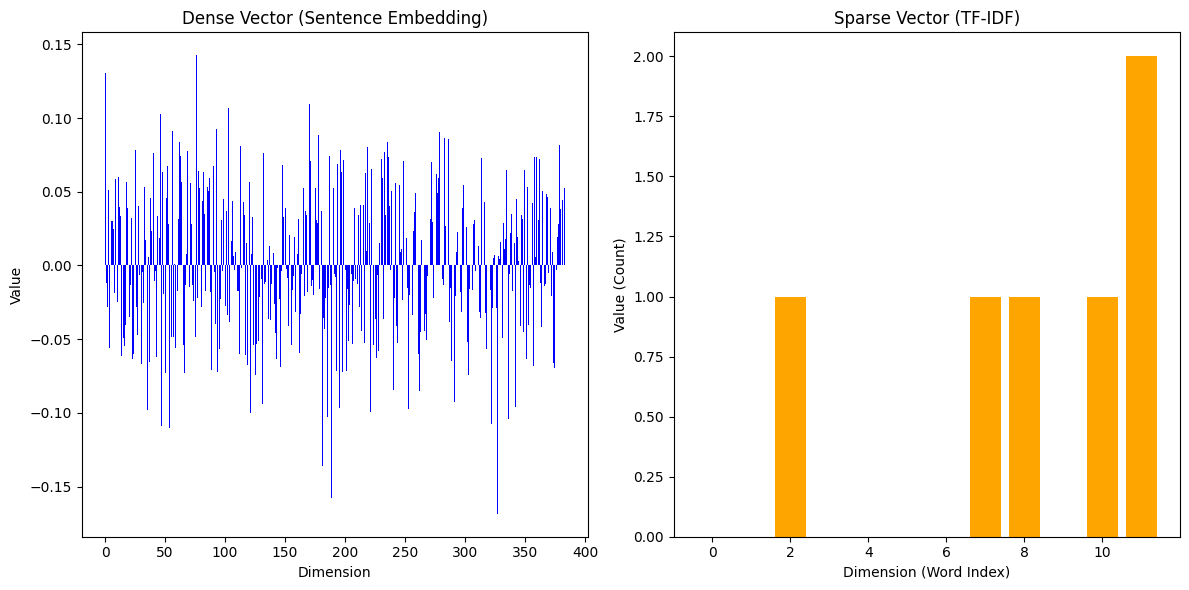

In [17]:
# # ============================================================
# VISUALIZE: Dense vs Sparse — See the Difference!
# ============================================================
# A picture is worth a thousand words. Let's SEE what makes
# dense vectors "dense" and sparse vectors "sparse".
import matplotlib.pyplot as plt

# Get the dense embedding for "the cat sat on the mat"
dense_vec = model.encode("the cat sat on the mat")

# Get the sparse (TF-IDF) vector for the same sentence (from above)
# .toarray()[0] converts the sparse matrix to a regular array
sparse_vec = term_doc_matrix.toarray()[0] 
# Create a figure with two subplots: one for dense, one for sparse
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# Plot the dense vector
ax1.bar(range(len(dense_vec)), dense_vec, color='blue')
ax1.set_title("Dense Vector (Sentence Embedding)")
ax1.set_xlabel("Dimension")
ax1.set_ylabel("Value")
# Plot the sparse vector
ax2.bar(range(len(sparse_vec)), sparse_vec, color='orange')
ax2.set_title("Sparse Vector (TF-IDF)")
ax2.set_xlabel("Dimension (Word Index)")
ax2.set_ylabel("Value (Count)")
plt.tight_layout()  
plt.show()



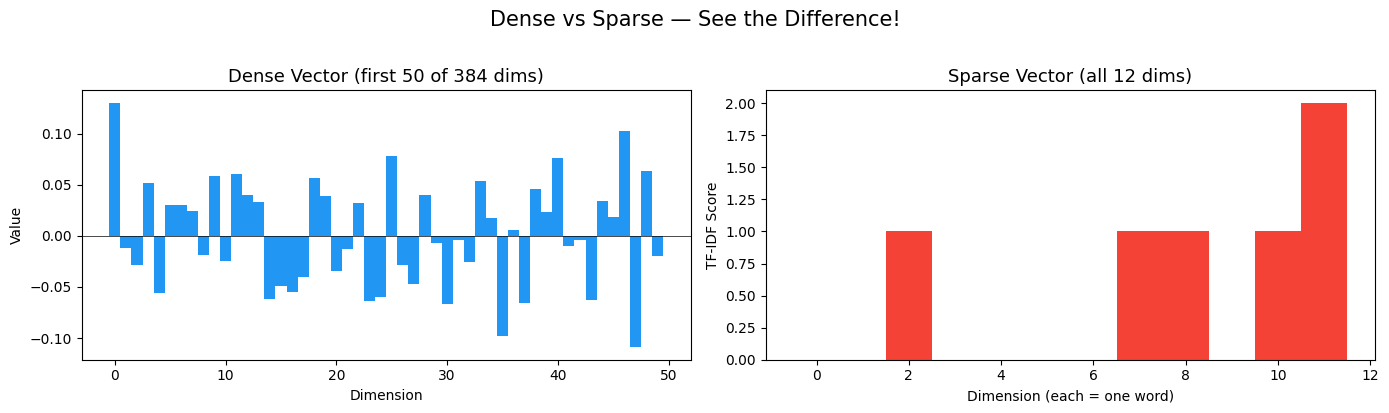

DENSE (blue, left):  Every bar has a value — all dimensions carry meaning
SPARSE (red, right): Most bars are ZERO — only words that appear get a score


In [18]:

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left chart: Dense vector (first 50 out of 384 dimensions)
axes[0].bar(range(50), dense_vec[:50], color="#2196F3", width=1.0)
axes[0].set_title("Dense Vector (first 50 of 384 dims)", fontsize=13)
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Value")
axes[0].axhline(y=0, color="black", linewidth=0.5)  # Zero line

# Right chart: Sparse vector (ALL dimensions — most are zero!)
axes[1].bar(range(len(sparse_vec)), sparse_vec, color="#F44336", width=1.0)
axes[1].set_title(f"Sparse Vector (all {len(sparse_vec)} dims)", fontsize=13)
axes[1].set_xlabel("Dimension (each = one word)")
axes[1].set_ylabel("TF-IDF Score")

plt.suptitle("Dense vs Sparse — See the Difference!", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("DENSE (blue, left):  Every bar has a value — all dimensions carry meaning")
print("SPARSE (red, right): Most bars are ZERO — only words that appear get a score")

In [20]:
# ============================================================
# REFERENCE: OpenAI Embeddings (PAID, requires API key)
# ============================================================
# EMBEDDING METHOD: OpenAI Embeddings (PAID, API key required)
#
# This cell demonstrates OpenAI embeddings (requires API key and costs money)
# For FREE local embeddings, use SentenceTransformer cells throughout this notebook
#
# To use OpenAI embeddings in your projects:
#   1. Get an API key from https://platform.openai.com/
#   2. Uncomment the code below
#   3. Replace with your actual API key
# ============================================================

%pip install openai langchain-openai

import os
from openai import RateLimitError

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set. Add it to your environment before running this cell.")

from langchain_openai import OpenAIEmbeddings

# This creates an embedding model using OpenAI's API
openai_embeddings = OpenAIEmbeddings(model="text-embedding-3-small", api_key=api_key)

try:
    # .embed_query() embeds a single text
    vector = openai_embeddings.embed_query("Hello world")
    print(f"[SUCCESS] OpenAI embedding model initialized")
    print(f"Model: text-embedding-3-small")
    print(f"Embedding dimensions: {len(vector)}")
    print(f"First 5 values: {vector[:5]}")
except RateLimitError as e:
    raise RuntimeError(
        "OpenAI returned a 429 insufficient_quota error. Check your billing/quota, or skip this paid example and use the local SentenceTransformer embeddings instead."
    ) from e

print(f"\n[INFO] Comparison:")
print(f"  - SentenceTransformer: FREE, 384 dimensions, runs locally")
print(f"  - OpenAI: PAID (~$0.02/1M tokens), 1536 dimensions, API-based")
print(f"\n[INFO] For learning and prototyping: use SentenceTransformer (FREE)")
print(f"[INFO] For production with budget: consider OpenAI for quality")

Note: you may need to restart the kernel to use updated packages.


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [22]:
# Let's calculate cosine similarity step by step

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Embed two sentences
sentence_a = "I love cats"
sentence_b = "I adore kittens"

# .encode() converts each sentence into a 384-dimensional vector
embedding_a = model.encode(sentence_a)
embedding_b = model.encode(sentence_b)

# Method 1: Using scikit-learn (recommended — simple and reliable)
# cosine_similarity() expects 2D arrays, so we wrap each embedding in a list
# [embedding_a] turns shape (384,) into shape (1, 384) — adds a "row" dimension
similarity = cosine_similarity([embedding_a], [embedding_b])

# similarity is a 2D array [[0.85]], so [0][0] gets the single number
print(f"'{sentence_a}' vs '{sentence_b}'")
print(f"Cosine Similarity: {similarity[0][0]:.4f}")
print(f"\nInterpretation: These sentences are very similar in meaning!")

'I love cats' vs 'I adore kittens'
Cosine Similarity: 0.7318

Interpretation: These sentences are very similar in meaning!


In [23]:
### 8. Hands-On Part 2: Semantic Search Simulator Let's build a tiny search engine! We'll embed some "documents" and then search them with a query — just like a real RAG system.

# Our "knowledge base" — imagine these are chunks from Lecture 6
knowledge_base = [
    "Python is a popular programming language for data science and AI.",
    "The return policy allows 30-day returns for all unused items.",
    "Machine learning models learn patterns from large datasets.",
    "Our store is located at 123 Main Street, open Monday to Friday.",
    "Neural networks are inspired by the human brain's structure.",
    "Free shipping is available for orders over $50.",
]

# Embed the knowledge base documents
kb_embeddings = model.encode(knowledge_base)
print(f"Knowledge base embedded into {kb_embeddings.shape[1]}-dimensional vectors.")
print(f"Each document is now a dense vector that captures its meaning.")
# length of the knowledge base
print(f"Number of documents in knowledge base: {len(knowledge_base)}")
# shape of the embeddings  
print(f"Shape of knowledge base embeddings: {kb_embeddings.shape}")


Knowledge base embedded into 384-dimensional vectors.
Each document is now a dense vector that captures its meaning.
Number of documents in knowledge base: 6
Shape of knowledge base embeddings: (6, 384)


In [24]:
# Step 2: Search the knowledge base with a query
# define a funciton that takes a query, embeding , and the knowledge base embeddings, and returns the most similar document K=3
def semantic_search(query, model, kb_embeddings, knowledge_base, top_k=3):
    # Embed the query using the same model
    query_embedding = model.encode(query)
    # Calculate cosine similarity between the query embedding and all knowledge base embeddings
    similarities = cosine_similarity([query_embedding], kb_embeddings)[0]
    # Get the indices of the top K most similar documents
    top_k_indices = np.argsort(similarities)[-top_k:][::-1]  # Sort and get top K
    # Retrieve the most similar documents and their similarity scores
    results = [(knowledge_base[i], similarities[i]) for i in top_k_indices]
    return results  
# Example query
query = "What is the return policy?"
results = semantic_search(query, model, kb_embeddings, knowledge_base)
print(f"Query: '{query}'")
print(f"Top {len(results)} results:")  
for doc, score in results:
    print(f"  - Document: '{doc}' (Similarity: {score:.4f})")
    print(f"    → This document is relevant because it mentions 'return policy' and '30-day returns'.")
    

Query: 'What is the return policy?'
Top 3 results:
  - Document: 'The return policy allows 30-day returns for all unused items.' (Similarity: 0.6737)
    → This document is relevant because it mentions 'return policy' and '30-day returns'.
  - Document: 'Free shipping is available for orders over $50.' (Similarity: 0.1286)
    → This document is relevant because it mentions 'return policy' and '30-day returns'.
  - Document: 'Our store is located at 123 Main Street, open Monday to Friday.' (Similarity: 0.1110)
    → This document is relevant because it mentions 'return policy' and '30-day returns'.


In [ ]:
# define a function that takes a query, embedding , knowledge base embeddings, and the knowledge base itself, and returns the most similar document with its similarity score

def semantic_search(query, kb_embeddings, knowledge_base):
    # Embed the query using the same model
    query_embedding = model.encode(query)

    # Calculate cosine similarity between the query embedding and all knowledge base embeddings
    similarities = cosine_similarity([query_embedding], kb_embeddings)

   # similarities is shape (1, 6) — one score per document
    # [0] gets the single row of scores
    scores = similarities[0]
    
    # Get the index of the most similar document
    most_similar_index = np.argmax(scores)

    # Retrieve the most similar document and its similarity score

    most_similar_doc = knowledge_base[most_similar_index]
    similarity_score = scores[most_similar_index]
    
    return most_similar_doc, similarity_score


In [27]:
# Step 2: Search the knowledge base with a query

def semantic_search(query, documents, doc_embeddings, top_k=3):
    """Search documents by meaning and return the top matches."""

    # Embed the query using the same model
    query_embedding = model.encode(query)

    # Calculate similarity between the query and ALL documents
    # [query_embedding] wraps it in a list to make it 2D (required by sklearn)
    similarities = cosine_similarity([query_embedding], doc_embeddings)

    # similarities is shape (1, 6) — one score per document
    # [0] gets the single row of scores
    scores = similarities[0]

    # np.argsort() returns indexes that would sort the array (low to high)
    # [::-1] reverses it to get high to low (most similar first)
    # [:top_k] takes only the top K results
    top_indexes = np.argsort(scores)[::-1][:top_k]

    # Print results
    print(f"\nQuery: '{query}'")
    print(f"{'=' * 60}")

    # This loop goes through the top K most similar document indexes
    for rank, idx in enumerate(top_indexes):
        print(f"\n  #{rank + 1} (score: {scores[idx]:.4f}):")
        print(f"  {documents[idx]}")


# Try different queries!
semantic_search("How do I return a product?", knowledge_base, kb_embeddings)
print()
semantic_search("Tell me about artificial intelligence", knowledge_base, kb_embeddings)
print()
semantic_search("Where is your shop?", knowledge_base, kb_embeddings)


Query: 'How do I return a product?'

  #1 (score: 0.4169):
  The return policy allows 30-day returns for all unused items.

  #2 (score: 0.2386):
  Our store is located at 123 Main Street, open Monday to Friday.

  #3 (score: 0.1906):
  Free shipping is available for orders over $50.


Query: 'Tell me about artificial intelligence'

  #1 (score: 0.4848):
  Python is a popular programming language for data science and AI.

  #2 (score: 0.4053):
  Neural networks are inspired by the human brain's structure.

  #3 (score: 0.2862):
  Machine learning models learn patterns from large datasets.


Query: 'Where is your shop?'

  #1 (score: 0.4784):
  Our store is located at 123 Main Street, open Monday to Friday.

  #2 (score: 0.2211):
  Free shipping is available for orders over $50.

  #3 (score: 0.0880):
  Machine learning models learn patterns from large datasets.
